In [1]:
from typing import Dict, TypedDict,List
from langgraph.graph import StateGraph, START, END

In [ ]:
# pip install langgraph


In [ ]:
class AgentState(TypedDict):
    message : str

def greeting_node(state: AgentState)->AgentState:
    """simple node that adds a greeting message to the state"""

    state['message'] = "Hey" + state["message"]

    return state

In [ ]:
graph = StateGraph(AgentState)
graph.add_node("greeter",greeting_node)
graph.set_entry_point("greeter")
graph.set_finish_point("greeter")
app = graph.compile()


In [ ]:
app

In [ ]:
res = app.invoke({"message" : "bob"})

In [ ]:
res["message"]

In [ ]:
class AgentState(TypedDict):
    message : str
def cheer(state:AgentState):
    state["message"] = state["message"] + "You are doing great job learning langraph"
    return state
graph = StateGraph(AgentState)
graph.add_node("cheer",cheer)
graph.set_entry_point("cheer")
graph.set_finish_point("cheer")
app = graph.compile()


In [ ]:
res = app.invoke({"message" : "bob"})

In [ ]:
res["message"]

In [ ]:
import math 
class AgentState(TypedDict):
    skills : List[str]
    name : str
    age: int
    result : str

def first_node(state:AgentState) -> AgentState:
     state["result"] = f"Hi {state['name']}"
     return state
def second_node(state:AgentState) -> AgentState:
     state["result"] = f"{state['result']}, your age is {state['age']}"
     return state
def third_node(state:AgentState) -> AgentState:
     state["result"] = f"{state['result']}, You have skills in {' '.join(state['skills'])}"
     return state
graph = StateGraph(AgentState) # Init the graph
graph.add_node("first node",first_node)#name, action
graph.add_node("second node",second_node)
graph.add_node("third node",third_node)

graph.set_entry_point("first node")
graph.add_edge("first node","second node")
graph.add_edge("second node","third node")
graph.set_finish_point("third node")

app = graph.compile()
app


In [ ]:
res = app.invoke({"skills":["banger","danger"],"name":"ziad","age":12})

In [ ]:
res["result"]

In [ ]:
import random
class AgentState(TypedDict):
    player_name: str
    guesses : List[int]

def guess(state:AgentState) -> AgentState:
    number = random.randint(0,20)
    lower = 0
    upper = 20



def decide_next_node(state:AgentState) -> AgentState:
    """This node will select the next node of the graph"""
    inp = input(int)
    state['guesses'].append(inp)
    if inp == number:

graph = StateGraph(AgentState)

graph.add_node("add_node", adder)
graph.add_node("subtract_node", subtractor)
graph.add_node("router", lambda state:state) # passthrough function

graph.add_edge(START, "router") 

graph.add_conditional_edges(
    "router",
    decide_next_node, 

    {
        # Edge: Node
        "addition_operation": "add_node",
        "subtraction_operation": "subtract_node"
    }

)

graph.add_edge("add_node", END)
graph.add_edge("subtract_node", END)

app = graph.compile()
app

In [14]:
import random
class AgentState(TypedDict):
 player_name: str
 guesses : List[str]
 attmepts : int
 lower:int
 upper:int
 guess:int
 number:int
 hint :str

def greeting(state:AgentState)->AgentState:
    state['player_name']=f"Hi{state['player_name']}"
    state['number'] = random.randint(0,20)
    state['lower']=0;state['upper']=20
    state['attempts'] = 7
    return state
    
    

def guess(state:AgentState)->AgentState:
    state['guess']=random.randint(state['lower'],state['upper'])
    return state
    
    
def hint_node(state:AgentState)->AgentState:
    if state['guess'] == state['number'] and state['attmepts'] > 0:
        state["attmepts"] -= 1
        print(f"Number guessed succesfully in {7-state['attmepts']}, the number is {state['number']}")
        return "exit"
    elif state['guess'] > state['number'] and state['attmepts'] > 0:
        state["attmepts"] -= 1
        state['upper'] = state['guess']
        print(f"Pick a smaller number!, upper is {state['upper']} and lower is {state['lower']}")
        return "loop"
    elif state['guess'] < state['number'] and state['attmepts'] > 0:
        state["attmepts"] -= 1
        state['lower'] = state['guess']
        print(f"Pick a bigger number! upper is {state['upper']} and lower is {state['lower']}")
        return "loop"
    else:
        print(f"Out of attempts")
        return "exit"

graph = StateGraph(AgentState)
graph.add_node("greeting",greeting)
graph.add_node("guess",guess)
graph.add_node("hint",hint_node)
graph.add_edge("greeting","guess")
graph.add_edge("guess","hint")

graph.add_conditional_edges(
    "hint",
    lambda state:hint_node(state),
    {
            "loop":"guess",
            "exit":END
    }

)

graph.set_entry_point("greeting")
    
app = graph.compile()

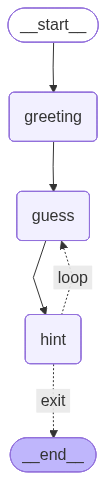

In [12]:
app

In [19]:

# Pass in the initial state to start the graph!
initial_state = {
    "player_name": "Ziad",
    "guesses": [],
    "attmepts": 0, # Note: spelled "attmepts" exactly as you defined it in your TypedDict
    "lower": 0,
    "upper": 20
}

# Run the graph
result = app.invoke(initial_state)

print("\n--- FINAL STATE ---")
print(result)


Out of attempts


InvalidUpdateError: Expected dict, got exit
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/INVALID_GRAPH_NODE_RETURN_VALUE

In [20]:
import random
class AgentState(TypedDict):
 player_name: str
 guesses : List[str]
 attmepts : int
 lower:int
 upper:int
 guess:int
 number:int
 hint :str

def greeting(state:AgentState)->AgentState:
    state['player_name']=f"Hi{state['player_name']}"
    state['number'] = random.randint(0,20)
    state['lower']=0;state['upper']=20
    state['attempts'] = 7
    return state
    
    

def guess(state:AgentState)->AgentState:
    state['guess']=random.randint(state['lower'],state['upper'])
    return state
    
    

# 1. THE NODE: Only does math and returns state updates (a dictionary!)
def hint_node(state: AgentState):
    if state['guess'] == state['number'] and state['attmepts'] > 0:
        print(f"Number guessed successfully in {7-state['attmepts']} tries! The number is {state['number']}")
        return {"attmepts": state["attmepts"] - 1} # Return dictionary
        
    elif state['guess'] > state['number'] and state['attmepts'] > 0:
        print(f"Guess {state['guess']} is too high! Upper is now {state['guess']} and lower is {state['lower']}")
        return {"attmepts": state["attmepts"] - 1, "upper": state["guess"]} # Return dictionary
        
    elif state['guess'] < state['number'] and state['attmepts'] > 0:
        print(f"Guess {state['guess']} is too low! Upper is {state['upper']} and lower is now {state['guess']}")
        return {"attmepts": state["attmepts"] - 1, "lower": state["guess"]} # Return dictionary
        
    else:
        print(f"Out of attempts! The number was {state['number']}")
        return {"attmepts": state["attmepts"] - 1} # Return dictionary

# 2. THE ROUTER: Only looks at the state and returns a string ("loop" or "exit")
def should_continue(state: AgentState):
    # If we guessed correctly, or we ran out of attempts -> EXIT
    if state['guess'] == state['number'] or state['attmepts'] <= 0:
        return "exit"
    # Otherwise -> LOOP
    else:
        return "loop"

# 3. THE GRAPH
graph = StateGraph(AgentState)
graph.add_node("greeting", greeting)
graph.add_node("guess", guess)
graph.add_node("hint", hint_node)

graph.add_edge("greeting", "guess")
graph.add_edge("guess", "hint") # Guess always goes to hint

# The hint node always goes to the router!
graph.add_conditional_edges(
    "hint", 
    should_continue, # Uses our new routing function!
    {
        "loop": "guess", # Go back and guess again
        "exit": END      # End the game
    }
)

graph.set_entry_point("greeting")
app = graph.compile() 


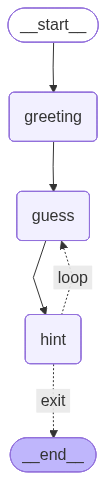

In [21]:
app

In [89]:

# Pass in the initial state to start the graph!
initial_state = {
    "player_name": "Ziad",
    "guesses": [],
    "attmepts": 0, # Note: spelled "attmepts" exactly as you defined it in your TypedDict
    "lower": 0,
    "upper": 20
}

# Run the graph
result = app.invoke(initial_state)

print("\n--- FINAL STATE ---")
print(result)


Out of attempts! The number was 11

--- FINAL STATE ---
{'player_name': 'HiZiad', 'guesses': [], 'attmepts': -1, 'lower': 0, 'upper': 20, 'guess': 6, 'number': 11}


In [ ]:
from typing import Dict, TypedDict,List
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import HumanMessage
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv

load_dotenv()

class AgentState(TypedDict):
    messages: List[HumanMessage]
# llm = ChatOpenAI(model="gpt-4o")
llm = ChatOpenAI(
    openai_api_key="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",
    openai_api_base="https://openrouter.ai/api/v1",
    model_name="tencent/hy3:free"

)

def process(state: AgentState)-> AgentState:
    res = llm.invoke(state["messages"])
    print(f"AI: {res.content}")
    return state

graph = StateGraph(AgentState)
graph.add_node("process",process)
graph.add_edge(START,"process")
graph.add_edge("process",END)
agent = graph.compile()

while user_input != "exit":
 user_input = input("Enter: ")
 agent.invoke({"messages":[HumanMessage(content=user_input)]})

AI: 好的，再见！如果您以后有任何问题或需要帮助，随时欢迎回来。祝您一切顺利！


{'messages': [HumanMessage(content='exit', additional_kwargs={}, response_metadata={})]}

In [ ]:
import os
from typing import Dict, TypedDict,List, Union
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import HumanMessage, AIMessage
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langchain_core.messages import messages_from_dict, messages_to_dict

class AgentState(TypedDict):
    message:List[HumanMessage]
    AI_message:List[Union[AIMessage,AIMessage]]
llm = ChatOpenAI(
    openai_api_key="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",
    openai_api_base="https://openrouter.ai/api/v1",
    model_name="tencent/hy3:free"

)

def process(state: AgentState)-> AgentState:
    res = llm.invoke(state["message"])
    print(f"AI: {res.content}")
    state["message"].append(AIMessage(content = res.content))
    return state

graph = StateGraph(AgentState)
graph.add_node("process",process)
graph.add_edge(START,"process")
graph.add_edge("process",END)
agent = graph.compile()
conversation_history=[]
user_input = ""
while user_input != "exit":
 user_input = input("Enter: ")
 print(user_input)
 conversation_history.append(HumanMessage(content=user_input))


 result = agent.invoke({"message":conversation_history})
 conversation_history = result["message"] #overwrites the old history

with open("logging.txt","w") as file:
    file.write("Your conversation log\n\n")
    for message in conversation_history:
        if isinstance(message,HumanMessage):
            file.write(f"User: {message.content}\n")
        elif isinstance(message,AIMessage):
            file.write(f"AI: {message.content}\n\n")
    file.write("End of conversation")
print("Conversation saved in logging.txt")



Hi
AI: Hello! How can I help you today? 😊
whats the latest date of training data that you've trained on
AI: I'm based on the Qwen model. My training data has a knowledge cutoff of **September 2024**. That means my training included information available up to around that time, and I don't have access to events or data generated after that date unless it's provided to me in our conversation.

Let me know if you'd like to know more about my capabilities or limitations!
what do you think would happen in 2026
AI: Since my training data ends in September 2024, I can’t predict the future with certainty — but I can share some **informed possibilities and trends** that experts were discussing around that time, which could shape 2026:

### 1. **AI & Technology**
- **More autonomous AI agents**: By 2026, we may see wider deployment of AI that can plan and execute multi-step tasks (e.g., coding, research, scheduling) with less human oversight.
- **Regulation maturing**: The EU AI Act and similar 

RateLimitError: Error code: 429 - {'error': {'message': 'Provider returned error', 'code': 429, 'metadata': {'raw': 'tencent/hy3:free is temporarily rate-limited upstream. Please retry shortly, or add your own key to accumulate your rate limits: https://openrouter.ai/settings/integrations', 'provider_name': 'Novita', 'is_byok': False}}, 'user_id': 'user_3DAWBeFerXFG7NhM48p4Pw7XTaq'}

In [21]:
conversation_history

[HumanMessage(content='hi', additional_kwargs={}, response_metadata={}),
 AIMessage(content='Hello! 👋 How can I help you today?', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='im ziad', additional_kwargs={}, response_metadata={}),
 AIMessage(content='Hey Ziad! Nice to meet you 😊 What can I help you with today?', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='whats my name', additional_kwargs={}, response_metadata={}),
 AIMessage(content="Your name is **Ziad** — you just told me a moment ago! 😄\n\nAnything you'd like to chat about or get help with?", additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='', additional_kwargs={}, response_metadata={}),
 AIMessage(content='Still here, Ziad! 👋 Let me know if you need anything.', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
 HumanMessag

In [22]:
result

{'message': [HumanMessage(content='hi', additional_kwargs={}, response_metadata={}),
  AIMessage(content='Hello! 👋 How can I help you today?', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='im ziad', additional_kwargs={}, response_metadata={}),
  AIMessage(content='Hey Ziad! Nice to meet you 😊 What can I help you with today?', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='whats my name', additional_kwargs={}, response_metadata={}),
  AIMessage(content="Your name is **Ziad** — you just told me a moment ago! 😄\n\nAnything you'd like to chat about or get help with?", additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='', additional_kwargs={}, response_metadata={}),
  AIMessage(content='Still here, Ziad! 👋 Let me know if you need anything.', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_call

In [ ]:
from typing import Annotated, Sequence, TypedDict
from dotenv import load_dotenv  
from langchain_core.messages import BaseMessage # The foundational class for all message types in LangGraph
from langchain_core.messages import ToolMessage # Passes data back to LLM after it calls a tool such as the content and the tool_call_id
from langchain_core.messages import SystemMessage # Message for providing instructions to the LLM
from langchain_openai import ChatOpenAI
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode

class AgentState(TypedDict):
    messages:Annotated[Sequence[BaseMessage],add_messages]

@tool 
def add(a: int,b: int):
  """add function"""
  return a+b
@tool 
def subtract(a: int,b: int):
  """subtract function"""
  return a-b
@tool 
def multiply(a: int,b: int):
  """multiply function"""
  return a*b

tools = [add,subtract,multiply]
llm = ChatOpenAI(
    openai_api_key="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",
    openai_api_base="https://openrouter.ai/api/v1",
    model_name="tencent/hy3:free"

).bind_tools(tools)

def model_call(state:AgentState)->AgentState:
  system_prompt = SystemMessage(content="You are an AI assistant")
  response = llm.invoke([system_prompt]+state["messages"])
  return {"messages":response}

def should_continue(state:AgentState):
  latest_message = state["messages"][-1]
  if hasattr(latest_message,"tool_calls") and len(latest_message.tool_calls)>0:
    print(f"The LLM wants to make {len(latest_message.tool_calls)} tool calls!")
    return "tools_node" # Route to the node that executes tools
  else:
    return "end"

graph = StateGraph(AgentState)

tool_node = ToolNode(tools=tools)
graph.add_node("tools", tool_node)

graph.add_node("model_call",model_call)
graph.add_edge(START,"model_call")


# The hint node always goes to the router!
graph.add_conditional_edges(
    "model_call", 
    should_continue, # Uses our new routing function!
    {
        "tools_node": "tools", # Go back and guess again
        "end": END      # End the game
    }
)
graph.add_edge("tools", "model_call")

app = graph.compile()

In [35]:
inputs = {"messages": [("user", "Add 40 + 12 and then multiply the result by 6. Also tell me a joke please.")]}
result = app.invoke(inputs)

print("\n--- FINAL STATE ---")
print(result)

The LLM wants to make 1 tool calls!
The LLM wants to make 1 tool calls!

--- FINAL STATE ---
{'messages': [HumanMessage(content='Add 40 + 12 and then multiply the result by 6. Also tell me a joke please.', additional_kwargs={}, response_metadata={}, id='666e0345-485c-4b10-adb4-156d56142ab4'), AIMessage(content="I'll calculate that for you step by step!", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 115, 'prompt_tokens': 349, 'total_tokens': 464, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 78, 'rejected_prediction_tokens': None, 'image_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': 0, 'cached_tokens': 128, 'video_tokens': 0}, 'cost': 0, 'is_byok': False, 'cost_details': {'upstream_inference_cost': 0, 'upstream_inference_prompt_cost': 0, 'upstream_inference_completions_cost': 0}}, 'model_provider': 'openai', 'model_name': 'tencent/hy3:free', 'syste

In [36]:
result["messages"][-1].pretty_print()

================================== Ai Message ==================================

The answer is **312**! (40 + 12 = 52, and 52 × 6 = 312)

And here's a joke for you:

Why don't scientists trust atoms?

Because they make up everything! 😄


In [37]:
# Pretty print every step so it's easy to read
for msg in result["messages"]:
    msg.pretty_print()



================================ Human Message =================================

Add 40 + 12 and then multiply the result by 6. Also tell me a joke please.
================================== Ai Message ==================================

I'll calculate that for you step by step!
Tool Calls:
  add (chatcmpl-tool-fc10eddbaf374ff29036f2bcb1cbf691)
 Call ID: chatcmpl-tool-fc10eddbaf374ff29036f2bcb1cbf691
  Args:
    a: 40
    b: 12
================================= Tool Message =================================
Name: add

52
================================== Ai Message ==================================

Now let me multiply that result by 6.
Tool Calls:
  multiply (chatcmpl-tool-e861b0dfd2724def8caa2b0c18d23f98)
 Call ID: chatcmpl-tool-e861b0dfd2724def8caa2b0c18d23f98
  Args:
    a: 52
    b: 6
================================= Tool Message =================================
Name: multiply

312
================================== Ai Message ==================================

The answer is

You are so close, but the very last part is slightly mixed up! Let's clean up the terminology.

Here is the exact cycle:

1. model_call (The LLM) builds the "Queue" It looks at the user's question, decides it needs tools, and generates an AIMessage that contains the tool_calls list. You are 100% correct: think of tool_calls as the queue of requested jobs.

2. should_continue acts as the Switchboard It looks at the message, sees there are jobs in the tool_calls queue, and switches the graph's path to send the state to the tools_node.

3. The tools_node processes the Queue (NOT model_call) This is the part to correct. The tools_node is a completely separate function from model_call. The tools_node takes the queue (tool_calls), loops through it, and actually runs your Python functions (the math). It takes the results (e.g., "10", "20") and adds them to the state as ToolMessages.

4. Back to model_call (The LLM) Once the tools_node is done, the graph automatically loops back to model_call. Now, the LLM looks at the conversation history, sees the ToolMessages containing the math answers, and says: "Ah, the math is done. The answers are 10 and 20." It then generates the final, normal text response to the user.

Visualizing the Loop:
User Input ➔ model_call (creates queue) ➔ should_continue (routes to tools) ➔ tools_node (runs python code, gets answers) ➔ LOOPS BACK ➔ model_call (reads answers, writes final reply) ➔ should_continue (sees queue is empty, routes to END) ➔ Done!

